<a href="https://colab.research.google.com/github/kimunilaz/Data_Structures-Algorithms_Final_Project/blob/main/Data_Structures%26Algorithms_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the data and building the graph**

This section reads the two input files.



*   Q2_road_network.csv gives 25 roads, each with two junctions and a travel time in minutes.
*   Q2_residential_areas.csv gives 18 residential areas and the junction where each one is located.






The road network is stored as an adjacency list: each junction maps to a list of (neighbour, travel time) pairs. Every road can be travelled in both directions, so each road is added twice, once from each end. The graph is undirected and weighted, with travel time as the weight.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time
import statistics
from itertools import combinations
from math import comb
from collections import defaultdict, deque


s_path = "https://raw.githubusercontent.com/kimunilaz/Data_Structures-Algorithms_Final_Project/main/"

def load_csv(filename):
    if os.path.exists(filename):
        return pd.read_csv(filename)          # running locally after cloning
    return pd.read_csv(s_path + filename)     # running in Colab, reads from GitHub

roads = load_csv("Q2_road_network.csv")
areas = load_csv("Q2_residential_areas.csv")

#print(roads.head(5))
#print(areas.head(5))

#building adjacency list

graph = defaultdict(list)

for _, row in roads.iterrows():
    a = row["from"]
    b = row["to"]
    t = row["minutes"]
    graph[a].append((b, t))
    graph[b].append((a, t))   # roads go both ways, so add both directions

junctions = sorted(graph.keys())


#testing
print("Number of junctions:", len(junctions))
print("Number of roads:", sum(len(v) for v in graph.values()) // 2)
print(graph["Curepipe"])



Number of junctions: 18
Number of roads: 25
[('Forest Side', 4), ('Floreal', 6)]


# **Dijkstra's algorithm**

Dijkstra's algorithm finds the shortest travel time from one starting junction to every other junction. It keeps a priority queue of junctions ordered by their best known time. It repeatedly takes the closest unvisited junction and updates its neighbours if a faster path through it is found. It also records each junction's previous junction on the shortest path.


**This is used in two ways:**


*   Fastest route: run from Curepipe, then follow the previous-junction records
back from Pamplemousses to rebuild the actual route, not just its total time.
*   Travel-time table: run once from every junction to get the shortest travel time between every junction and every area. The coverage step uses this table.





Dijkstra works here because all travel times are positive.

In [2]:
import heapq

def dijkstra(graph, start):
    dist = {j: float("inf") for j in graph}
    prev = {j: None for j in graph}
    dist[start] = 0

    pq = [(0, start)]     # (time so far, junction)
    visited = set()
    relaxations = 0

    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)

        for v, t in graph[u]:
            new_time = d + t
            if new_time < dist[v]:          # found a faster way to reach v
                dist[v] = new_time
                prev[v] = u
                heapq.heappush(pq, (new_time, v))
                relaxations += 1

    return dist, prev, relaxations


def get_route(prev, start, end):
    route = []
    current = end
    while current is not None:
        route.append(current)
        if current == start:
            break
        current = prev[current]
    route.reverse()
    if route[0] != start:      # end can't be reached from start
        return None
    return route


# Fastest route from Curepipe to Pamplemousses
dist, prev, relax = dijkstra(graph, "Curepipe")
route = get_route(prev, "Curepipe", "Pamplemousses")

print("Fastest route:", " → ".join(route))
print("Travel time:", dist["Pamplemousses"], "minutes")
print("Relaxations:", relax)


# Travel-time table: shortest time from every junction to every other junction
travel_time = {}
for j in junctions:
    d, _, _ = dijkstra(graph, j)
    travel_time[j] = d


# Checks
assert dist["Curepipe"] == 0
assert route[0] == "Curepipe" and route[-1] == "Pamplemousses"

# The route's total from the road times should equal Dijkstra's answer
route_total = 0
for a, b in zip(route, route[1:]):
    route_total += min(t for v, t in graph[a] if v == b)
assert route_total == dist["Pamplemousses"]

# Roads go both ways, so the table should be symmetric
for a in junctions:
    for b in junctions:
        assert travel_time[a][b] == travel_time[b][a]

print("All checks passed")

Fastest route: Curepipe → Forest Side → Phoenix → Quatre Bornes → Rose Hill → Beau Bassin → Port Louis → Terre Rouge → Pamplemousses
Travel time: 59 minutes
Relaxations: 19
All checks passed


# **Coverage**

A stop covers an area if the shortest travel time between the stop's junction and the area's junction is at most nine minutes. Exactly nine minutes counts as covered.


Using the travel-time table from section 2, this section builds a coverage set for each junction: the areas a stop at that junction would cover. Both the greedy method and the exhaustive search use these same sets, so they are compared on identical coverage rules.

In [3]:
COVER_LIMIT = 9   # minutes; exactly 9 counts as covered

# Which junction each area sits at
area_junction = {}
for _, row in areas.iterrows():
    area_junction[row["area"]] = row["sits_at_junction"]

# Every area junction must exist in the road network
for a, j in area_junction.items():
    assert j in graph, f"Area {a} sits at {j}, which is not in the road network"

# For each junction, the set of areas a stop there would cover
coverage = {}
for j in junctions:
    covered = set()
    for a, aj in area_junction.items():
        if travel_time[j][aj] <= COVER_LIMIT:
            covered.add(a)
    coverage[j] = covered


# Show the results
print(f"{'Junction':<20} {'Areas covered':>13}")
for j in junctions:
    print(f"{j:<20} {len(coverage[j]):>13}")


# Checks
assert len(area_junction) == 18

# A stop at an area's own junction is 0 minutes away, so it must cover that area
for a, aj in area_junction.items():
    assert a in coverage[aj]

print("Coverage checks passed")

Junction             Areas covered
Arsenal                          3
Beau Bassin                      3
Curepipe                         3
Ebene                            5
Floreal                          3
Forest Side                      3
Moka                             4
Pailles                          3
Pamplemousses                    2
Phoenix                          4
Port Louis                       3
Quatre Bornes                    6
Reduit                           3
Rose Hill                        3
St Pierre                        2
Terre Rouge                      3
Trou aux Biches                  1
Vacoas                           4
Coverage checks passed


# **Greedy stop placement**

This is the main method. It chooses six stops one at a time. At each step it adds the junction that covers the most areas not already covered by the stops chosen so far. Once a stop is chosen, it is never removed or changed.

If two or more junctions cover the same number of new areas, the one whose name comes first alphabetically is chosen. This makes the result fixed and repeatable.

Greedy is fast, but it is not guaranteed to find the best set of six. It only looks at the best choice at each step, not at how choices work together.

In [4]:
NUM_STOPS = 6

def greedy_stops(coverage, junctions, k):
    chosen = []
    covered = set()
    checks = 0          # operation count: how many junctions were evaluated

    for step in range(1, k + 1):
        best = None
        best_gain = -1

        # Going through junctions in alphabetical order and only replacing
        # on a strictly bigger gain means ties go to the earlier name
        for j in sorted(junctions):
            if j in chosen:
                continue
            gain = len(coverage[j] - covered)   # areas this stop would newly cover
            checks += 1
            if gain > best_gain:
                best = j
                best_gain = gain

        chosen.append(best)
        covered |= coverage[best]
        print(f"Stop {step}: {best:<20} new areas: {best_gain:>2}   total covered: {len(covered)}")

    return chosen, covered, checks


greedy_chosen, greedy_covered, greedy_checks = greedy_stops(coverage, junctions, NUM_STOPS)

print("\nGreedy stops:", greedy_chosen)
print("Areas covered:", len(greedy_covered), "out of", len(area_junction))
print("Uncovered areas:", sorted(set(area_junction) - greedy_covered))
print("Junctions evaluated:", greedy_checks)


# Checks
assert len(greedy_chosen) == NUM_STOPS
assert len(set(greedy_chosen)) == NUM_STOPS          # no junction picked twice

union = set()
for j in greedy_chosen:
    union |= coverage[j]
assert union == greedy_covered

print("Greedy checks passed")

Stop 1: Quatre Bornes        new areas:  6   total covered: 6
Stop 2: Arsenal              new areas:  3   total covered: 9
Stop 3: Curepipe             new areas:  3   total covered: 12
Stop 4: Ebene                new areas:  3   total covered: 15
Stop 5: Moka                 new areas:  1   total covered: 16
Stop 6: Pailles              new areas:  1   total covered: 17

Greedy stops: ['Quatre Bornes', 'Arsenal', 'Curepipe', 'Ebene', 'Moka', 'Pailles']
Areas covered: 17 out of 18
Uncovered areas: ['Trou aux Biches']
Junctions evaluated: 93
Greedy checks passed


# **Exhaustive search (baseline)**

This is the baseline the greedy method is compared against. It tries every possible set of six junctions out of 18, which is C(18, 6) = 18,564 combinations. For each set it counts how many areas are covered, and it keeps the best.

Because it checks every option, the result is the true maximum coverage. The gap between this number and the greedy result shows how far greedy fell short on this network.

A counter records how many combinations were checked, alongside the measured running time.

In [5]:
from itertools import combinations
from math import comb

def exhaustive_stops(coverage, junctions, k):
    best_count = -1
    best_sets = []        # every set that reaches the best count
    checked = 0           # operation count: how many combinations were tried

    for combo in combinations(sorted(junctions), k):
        checked += 1
        covered = set()
        for j in combo:
            covered |= coverage[j]
        n = len(covered)

        if n > best_count:
            best_count = n
            best_sets = [combo]
        elif n == best_count:
            best_sets.append(combo)

    return best_count, best_sets, checked


best_count, best_sets, combos_checked = exhaustive_stops(coverage, junctions, NUM_STOPS)
greedy_count = len(greedy_covered)
gap = best_count - greedy_count

print("Combinations checked:", combos_checked)
print("Best possible coverage:", best_count, "areas")
print("Number of best sets:", len(best_sets))
print("Example best set:", best_sets[0])
print()
print("Greedy coverage:", greedy_count, "areas")
print("Gap:", gap, "areas")


# Checks
assert combos_checked == comb(len(junctions), NUM_STOPS)   # 18,564
assert best_count >= greedy_count      # exhaustive can never do worse than greedy

print("Exhaustive checks passed")

Combinations checked: 18564
Best possible coverage: 18 areas
Number of best sets: 3
Example best set: ('Arsenal', 'Curepipe', 'Moka', 'Pailles', 'Quatre Bornes', 'Trou aux Biches')

Greedy coverage: 17 areas
Gap: 1 areas
Exhaustive checks passed


## **Helpers**

This prepares functions used by the rest of the notebook. It replaces the earlier greedy stop placement function with a version that only prints when asked, so timing doesn't measure printing. The rule is unchanged. It also adds build_graph and build_coverage, which build a graph and its coverage sets for any network, so the same greedy and exhaustive code can run on the two small constructed instances. A check confirms the new greedy gives the same answer as the earlier greedy stop placement.

In [6]:

def greedy_stops(coverage, junctions, k, verbose=False):
    chosen = []
    covered = set()
    checks = 0

    for step in range(1, k + 1):
        best, best_gain = None, -1
        for j in sorted(junctions):
            if j in chosen:
                continue
            gain = len(coverage[j] - covered)
            checks += 1
            if gain > best_gain:
                best, best_gain = j, gain
        chosen.append(best)
        covered |= coverage[best]
        if verbose:
            print(f"Stop {step}: {best:<20} new areas: {best_gain:>2}   total covered: {len(covered)}")

    return chosen, covered, checks


def exhaustive_stops(coverage, junctions, k):
    best_count, best_sets, checked = -1, [], 0
    for combo in combinations(sorted(junctions), k):
        checked += 1
        covered = set()
        for j in combo:
            covered |= coverage[j]
        n = len(covered)
        if n > best_count:
            best_count, best_sets = n, [combo]
        elif n == best_count:
            best_sets.append(combo)
    return best_count, best_sets, checked


def build_graph(road_list):
    """road_list: list of (junction_a, junction_b, minutes). Roads go both ways."""
    g = defaultdict(list)
    for a, b, t in road_list:
        g[a].append((b, t))
        g[b].append((a, t))
    return g


def build_coverage(g, area_to_junction, limit=9):
    """For every junction, the set of areas within `limit` minutes (limit counts)."""
    table = {j: dijkstra(g, j)[0] for j in g}
    cov = {}
    for j in g:
        cov[j] = {a for a, aj in area_to_junction.items() if table[j][aj] <= limit}
    return cov


def compare(name, g, area_to_junction, k, limit=9):
    """Run greedy and exhaustive on one instance and print both results."""
    cov = build_coverage(g, area_to_junction, limit)
    js = sorted(g.keys())
    print(f"--- {name}: {len(js)} junctions, {len(area_to_junction)} areas, {k} stops ---")
    g_chosen, g_cov, _ = greedy_stops(cov, js, k, verbose=True)
    b_count, b_sets, _ = exhaustive_stops(cov, js, k)
    print(f"Greedy stops:     {g_chosen}  -> {len(g_cov)} areas")
    print(f"Best possible:    {list(b_sets[0])}  -> {b_count} areas")
    print(f"Gap:              {b_count - len(g_cov)} areas\n")
    return len(g_cov), b_count


# Sanity check: the new greedy gives the same answer as section 4
check_chosen, check_covered, _ = greedy_stops(coverage, junctions, NUM_STOPS)
assert check_chosen == greedy_chosen and check_covered == greedy_covered
print("Helpers ready; greedy matches section 4")

Helpers ready; greedy matches section 4


# **Timing and operation counts**

Requirement 4 asks for measured running times beside the Big-O analysis. Each method is run several times untimed as a warm-up, then timed five times, and the median is reported. Dijkstra and the coverage table are shared by both methods, so they are timed separately and only greedy and exhaustive are compared. Operation counts are printed beside the times: junctions evaluated for greedy and combinations checked for exhaustive.

The second part varies the number of stops from 1 to 9 and plots time against combinations checked. A straight line means the measurements agree with the analysis.

Part                              Median time (ms)    Operations
Shared: Dijkstra x18 + coverage              0.519           352  (relaxations)
Greedy                                       0.033            93  (junctions evaluated)
Exhaustive                                  13.213         18564  (combinations checked)

Exhaustive / greedy: 404x slower in time, 200x more operations
k=1: combinations=    18   median time=    0.005 ms   time per combination=0.29 us
k=2: combinations=   153   median time=    0.055 ms   time per combination=0.36 us
k=3: combinations=   816   median time=    0.400 ms   time per combination=0.49 us
k=4: combinations=  3060   median time=    2.441 ms   time per combination=0.80 us
k=5: combinations=  8568   median time=    5.888 ms   time per combination=0.69 us
k=6: combinations= 18564   median time=   13.384 ms   time per combination=0.72 us
k=7: combinations= 31824   median time=   27.399 ms   time per combination=0.86 us
k=8: combinations= 43758   median

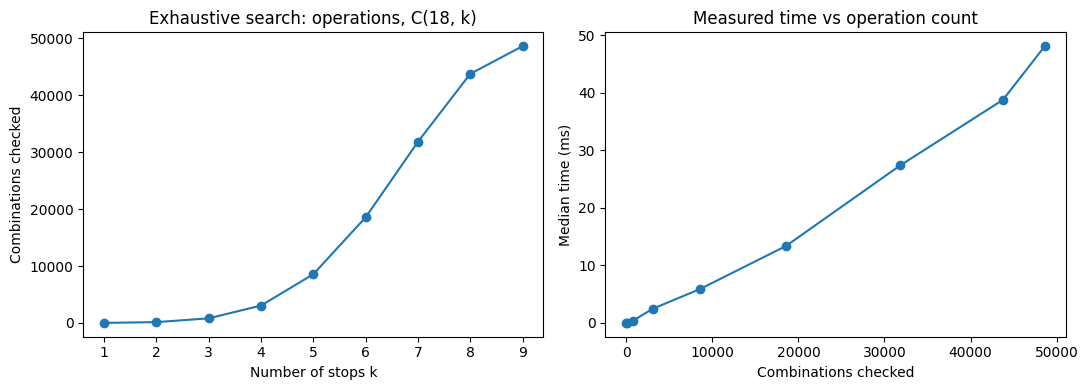

In [7]:
# Timing and operation counts (requirement 4)
# Method: Python is not JIT-compiled, but the first call still pays for
# cache warm-up and memory allocation, so each method is run a few times
# untimed first. Then 5 timed runs; the median is reported. Operation
# counts are reported beside the clock.
# Only the part that differs is timed. Dijkstra and the coverage table
# are shared by both methods, so they are timed separately and once.

WARMUP_RUNS = 20
TIMED_RUNS = 5


def median_time(fn, warmup=WARMUP_RUNS, runs=TIMED_RUNS):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    return statistics.median(times) * 1000   # milliseconds


# Shared work: Dijkstra from every junction + coverage sets
shared_ms = median_time(lambda: build_coverage(graph, area_junction, COVER_LIMIT), warmup=3)
total_relaxations = sum(dijkstra(graph, j)[2] for j in junctions)

# The two methods being compared
greedy_ms = median_time(lambda: greedy_stops(coverage, junctions, NUM_STOPS))
exhaustive_ms = median_time(lambda: exhaustive_stops(coverage, junctions, NUM_STOPS), warmup=2)

_, _, greedy_ops = greedy_stops(coverage, junctions, NUM_STOPS)
_, _, exhaustive_ops = exhaustive_stops(coverage, junctions, NUM_STOPS)

print(f"{'Part':<32}{'Median time (ms)':>18}{'Operations':>14}")
print(f"{'Shared: Dijkstra x18 + coverage':<32}{shared_ms:>18.3f}{total_relaxations:>14}  (relaxations)")
print(f"{'Greedy':<32}{greedy_ms:>18.3f}{greedy_ops:>14}  (junctions evaluated)")
print(f"{'Exhaustive':<32}{exhaustive_ms:>18.3f}{exhaustive_ops:>14}  (combinations checked)")
print(f"\nExhaustive / greedy: {exhaustive_ms / greedy_ms:.0f}x slower in time, "
      f"{exhaustive_ops / greedy_ops:.0f}x more operations")


# Does time grow in line with the operation count?
# Vary the number of stops k on the same network: combinations = C(18, k).
ks = list(range(1, 10))
k_ops, k_ms = [], []
for k in ks:
    _, _, ops = exhaustive_stops(coverage, junctions, k)
    ms = median_time(lambda: exhaustive_stops(coverage, junctions, k), warmup=1)
    k_ops.append(ops)
    k_ms.append(ms)
    print(f"k={k}: combinations={ops:>6}   median time={ms:9.3f} ms   "
          f"time per combination={ms * 1000 / ops:.2f} us")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, k_ops, marker="o")
ax[0].set_xlabel("Number of stops k")
ax[0].set_ylabel("Combinations checked")
ax[0].set_title("Exhaustive search: operations, C(18, k)")
ax[1].plot(k_ops, k_ms, marker="o")
ax[1].set_xlabel("Combinations checked")
ax[1].set_ylabel("Median time (ms)")
ax[1].set_title("Measured time vs operation count")
plt.tight_layout()
plt.show()


# **Two instances: greedy loses and greedy matches (requirement 3)**

Requirement 3 asks for one instance where the two methods differ and one where they don't.

Instance A: three hub junctions. The middle hub reaches some areas from each of the other two hubs, so it covers the most on its own. Greedy picks it first, can't undo that choice, and ends 2 areas short of the best pair.

Instance B: the same layout with no overlap, and greedy finds the best answer.

In [8]:

# Instance A: greedy LOSES clearly.
# 13 areas, each at its own junction (A01..A13). Three hub junctions:
#   Hub_L reaches A01-A06, Hub_R reaches A07-A12, each road 5 minutes.
#   Hub_M reaches A01-A03, A07-A09 and A13, each road 5 minutes.
# Any two areas are 10 minutes apart (via a hub), so only hubs cover
# more than one area. With 2 stops:
#   Greedy takes Hub_M first (7 areas, the most), then can only add 3.
#   Best is Hub_L + Hub_R = 12 areas.
# Hub_M looks best on its own because it overlaps both good stops,
# and once it is chosen it is never removed.

ROAD_TIME = 5
roads_A = []
for i in range(1, 7):
    roads_A.append(("Hub_L", f"A{i:02d}", ROAD_TIME))
for i in range(7, 13):
    roads_A.append(("Hub_R", f"A{i:02d}", ROAD_TIME))
for i in [1, 2, 3, 7, 8, 9, 13]:
    roads_A.append(("Hub_M", f"A{i:02d}", ROAD_TIME))

graph_A = build_graph(roads_A)
areas_A = {f"Area {i:02d}": f"A{i:02d}" for i in range(1, 14)}
greedy_A, best_A = compare("Instance A (greedy loses)", graph_A, areas_A, k=2)
assert best_A - greedy_A == 2


# Instance B: greedy MATCHES the best answer.
# Same layout, but the hubs do not overlap: Hub_L reaches A01-A06,
# Hub_R reaches A07-A12, Hub_M reaches only A13. No stop can steal
# areas from another, so taking the biggest first is also optimal.

roads_B = []
for i in range(1, 7):
    roads_B.append(("Hub_L", f"A{i:02d}", ROAD_TIME))
for i in range(7, 13):
    roads_B.append(("Hub_R", f"A{i:02d}", ROAD_TIME))
roads_B.append(("Hub_M", "A13", ROAD_TIME))
# connect the three hubs so the network is one piece (12 min: too far to cover)
roads_B += [("Hub_L", "Hub_M", 12), ("Hub_M", "Hub_R", 12)]

graph_B = build_graph(roads_B)
areas_B = {f"Area {i:02d}": f"A{i:02d}" for i in range(1, 14)}
greedy_B, best_B = compare("Instance B (greedy matches)", graph_B, areas_B, k=2)
assert best_B == greedy_B

--- Instance A (greedy loses): 16 junctions, 13 areas, 2 stops ---
Stop 1: Hub_M                new areas:  7   total covered: 7
Stop 2: Hub_L                new areas:  3   total covered: 10
Greedy stops:     ['Hub_M', 'Hub_L']  -> 10 areas
Best possible:    ['Hub_L', 'Hub_R']  -> 12 areas
Gap:              2 areas

--- Instance B (greedy matches): 16 junctions, 13 areas, 2 stops ---
Stop 1: Hub_L                new areas:  6   total covered: 6
Stop 2: Hub_R                new areas:  6   total covered: 12
Greedy stops:     ['Hub_L', 'Hub_R']  -> 12 areas
Best possible:    ['Hub_L', 'Hub_R']  -> 12 areas
Gap:              0 areas



# **Growth of exhaustive search**

This compares two ways the network could grow. With the number of stops fixed at 6, the number of combinations is C(V, 6), a polynomial of degree 6. Doubling V multiplies the work by about 64. That's slow, but it is not intractable.

If the number of stops grows with the network, with one stop for every three junctions, the count C(V, V/3) grows exponentially. NP-hardness refers to this second case. The table converts both into time using the speed measured in the timing cell.

    V               C(V, 6)  x prev                   C(V, V/3)        x prev
   18                18,564       -                   1.856e+04             -
   36             1,947,792   104.9                   1.252e+09      6.74e+04
   72           156,238,908    80.2                   7.950e+18      6.35e+09
  144        11,143,364,232    71.3                   4.509e+38      5.67e+19
  288       752,068,773,456    67.5                   2.044e+78      4.53e+39

At 0.71 us per combination (measured):
  V= 18: k=6 takes       0.0132 s,  k=V/3 takes       0.0132 s (4.19e-10 years)
  V= 36: k=6 takes         1.39 s,  k=V/3 takes          891 s (2.83e-05 years)
  V= 72: k=6 takes          111 s,  k=V/3 takes     5.66e+12 s (1.8e+05 years)
  V=144: k=6 takes     7.93e+03 s,  k=V/3 takes     3.21e+32 s (1.02e+25 years)
  V=288: k=6 takes     5.35e+05 s,  k=V/3 takes     1.46e+72 s (4.62e+64 years)


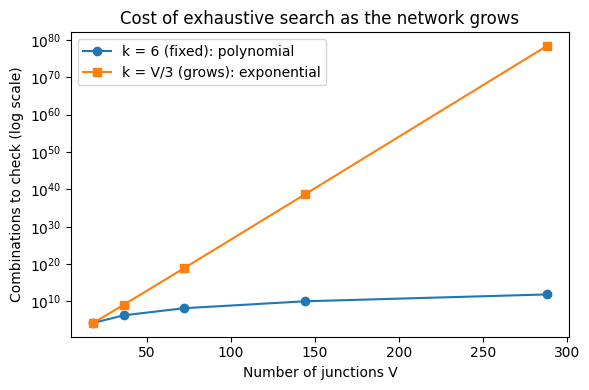

In [9]:

# Case 1: stops fixed at 6. C(V, 6) is a degree-6 polynomial in V, so
# doubling V multiplies the work by about 2^6 = 64.


# Case 2: one stop per three junctions, k = V/3. C(V, V/3) grows
#exponentially in V. This is the case NP-hardness is about:
#the problem size includes k, and no known algorithm avoids
#exponential growth when k grows with the network.

sizes = [18, 36, 72, 144, 288]
print(f"{'V':>5}{'C(V, 6)':>22}{'x prev':>8}{'C(V, V/3)':>28}{'x prev':>14}")
prev_fixed = prev_grow = None
fixed_vals, grow_vals = [], []
for V in sizes:
    fixed = comb(V, 6)
    grow = comb(V, V // 3)
    fixed_vals.append(fixed)
    grow_vals.append(grow)
    r1 = f"{fixed / prev_fixed:.1f}" if prev_fixed else "-"
    r2 = f"{grow / prev_grow:.2e}" if prev_grow else "-"
    print(f"{V:>5}{fixed:>22,}{r1:>8}{grow:>28.3e}{r2:>14}")
    prev_fixed, prev_grow = fixed, grow

# Seconds needed at the per-combination speed measured in the timing cell
sec_per_combo = (exhaustive_ms / 1000) / exhaustive_ops
print(f"\nAt {sec_per_combo * 1e6:.2f} us per combination (measured):")
for V, f, g in zip(sizes, fixed_vals, grow_vals):
    print(f"  V={V:>3}: k=6 takes {f * sec_per_combo:12.3g} s,  "
          f"k=V/3 takes {g * sec_per_combo:12.3g} s ({g * sec_per_combo / 3.15e7:.3g} years)")

plt.figure(figsize=(6, 4))
plt.semilogy(sizes, fixed_vals, marker="o", label="k = 6 (fixed): polynomial")
plt.semilogy(sizes, grow_vals, marker="s", label="k = V/3 (grows): exponential")
plt.xlabel("Number of junctions V")
plt.ylabel("Combinations to check (log scale)")
plt.title("Cost of exhaustive search as the network grows")
plt.legend()
plt.tight_layout()
plt.show()

# **Limitations**
Travel times are fixed, with no traffic or time of day.

Every area counts the same, whatever its population; the nine-minute cut-off is a hard line.

Stops are chosen for coverage and need not lie on the fastest route.

Greedy’s result depends on the tie-break, and exhaustive search does not scale when k grows.

Timings come from a shared Colab machine and vary between runs; operation counts do not.

# **Summary**
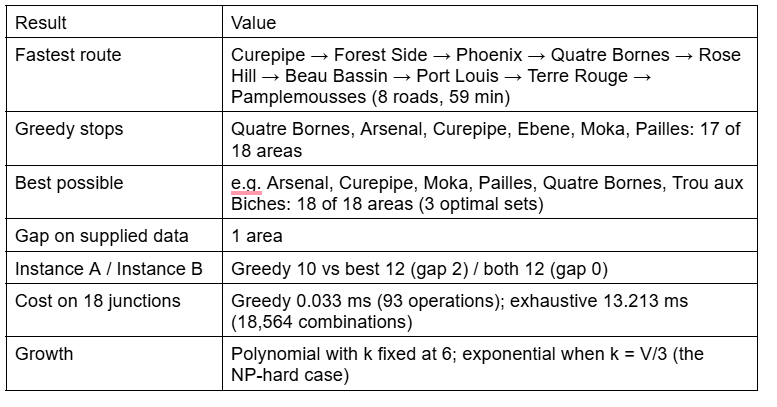
